In [18]:
import numpy as np
import pandas as pd


In [19]:
from sklearn.datasets import load_diabetes

In [20]:
data=load_diabetes()

In [21]:
print(data['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [22]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [23]:
df=pd.DataFrame(data.data,columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [24]:
X=df
y=data['target']

In [25]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)


In [27]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.140710,0.253976,0.332898,0.285181,0.246205,-0.096245,0.235710,0.298446,0.335580
sex,0.140710,1.000000,0.090254,0.230440,0.018052,0.131869,-0.376710,0.334837,0.133988,0.244798
bmi,0.253976,0.090254,1.000000,0.462804,0.246581,0.264401,-0.367280,0.406074,0.428514,0.408969
bp,0.332898,0.230440,0.462804,1.000000,0.279108,0.213358,-0.183503,0.294774,0.425550,0.464641
s1,0.285181,0.018052,0.246581,0.279108,1.000000,0.886521,0.074842,0.521647,0.516261,0.324188
s2,0.246205,0.131869,0.264401,0.213358,0.886521,1.000000,-0.183994,0.645312,0.295591,0.283299
s3,-0.096245,-0.376710,-0.367280,-0.183503,0.074842,-0.183994,1.000000,-0.739259,-0.364133,-0.278220
s4,0.235710,0.334837,0.406074,0.294774,0.521647,0.645312,-0.739259,1.000000,0.594880,0.417347
s5,0.298446,0.133988,0.428514,0.425550,0.516261,0.295591,-0.364133,0.594880,1.000000,0.468905
s6,0.335580,0.244798,0.408969,0.464641,0.324188,0.283299,-0.278220,0.417347,0.468905,1.000000


In [28]:
from sklearn.tree import DecisionTreeRegressor

In [29]:
model = DecisionTreeRegressor(criterion='squared_error', 
                              max_depth=3, 
                              max_features='sqrt', #number of features to consider when looking for the best split
                              splitter='best')

In [30]:
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3, max_features='sqrt')

Visualize decision tree

[Text(0.5, 0.875, 'x[8] <= -0.004\nsquared_error = 5787.821\nsamples = 353\nvalue = 150.779'),
 Text(0.25, 0.625, 'x[9] <= -0.032\nsquared_error = 3022.322\nsamples = 174\nvalue = 106.925'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[3] <= 0.048\nsquared_error = 2442.019\nsamples = 71\nvalue = 97.423'),
 Text(0.0625, 0.125, 'squared_error = 2098.616\nsamples = 70\nvalue = 95.114'),
 Text(0.1875, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 259.0'),
 Text(0.375, 0.375, 'x[8] <= -0.073\nsquared_error = 3317.181\nsamples = 103\nvalue = 113.476'),
 Text(0.3125, 0.125, 'squared_error = 597.84\nsamples = 5\nvalue = 55.4'),
 Text(0.4375, 0.125, 'squared_error = 3275.063\nsamples = 98\nvalue = 116.439'),
 Text(0.75, 0.625, 'x[8] <= 0.028\nsquared_error = 4789.426\nsamples = 179\nvalue = 193.408'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[9] <= 0.038\nsquared_error = 5329.44\nsamples = 77\nvalue = 171.429'),
 Text(0.5625, 0.125, 'squared_error = 4524.441\nsamples = 5

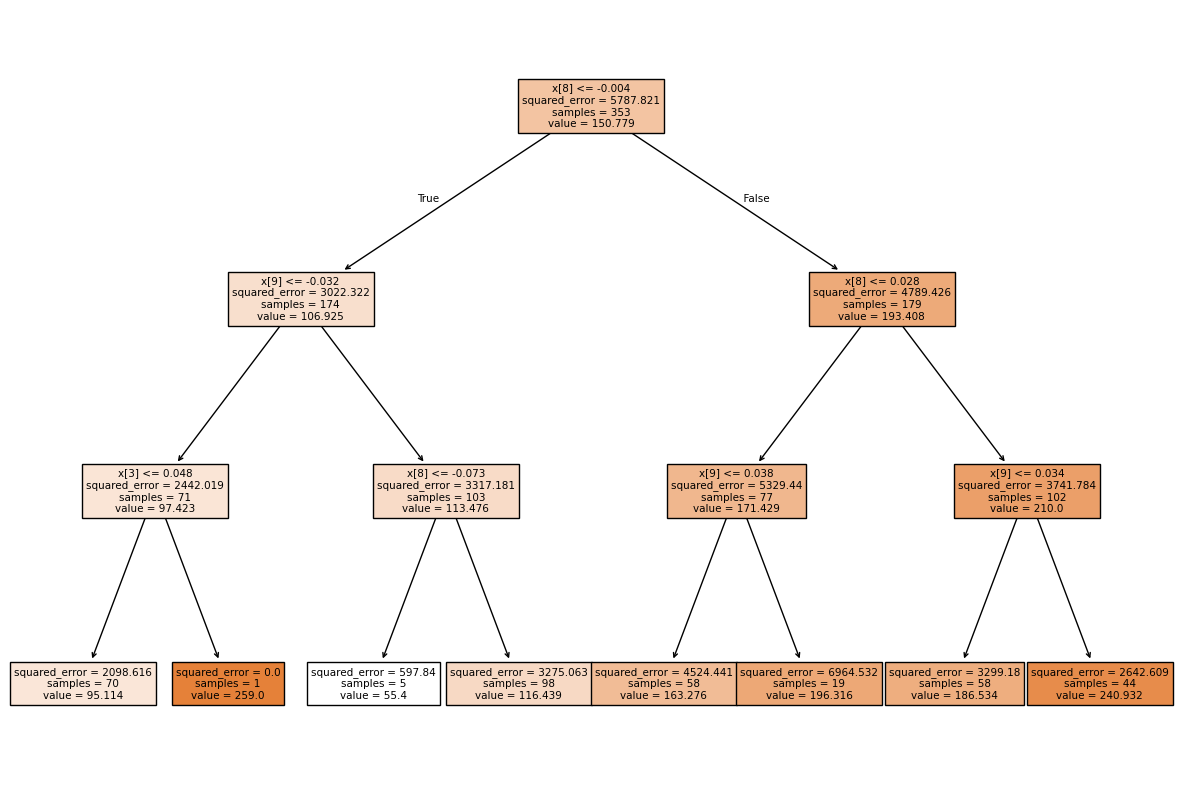

In [31]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True)

In [32]:
y_pred=model.predict(X_test)

In [33]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [34]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.2806723424278239
55.541341032908534
4644.854247155057
